# Reconocimiento Facial — Práctica
| IA 5.2 Computer Vision  
| FCEIA - UNR

En esta práctica implementamos un **sistema completo de reconocimiento facial** usando PyTorch.
Recorremos las 4 tareas fundamentales de forma secuencial, donde cada una construye sobre la anterior:

1. **Detección** — ¿Hay caras en la imagen? ¿Dónde están?
2. **Verificación (1:1)** — ¿Son la misma persona estas dos caras?
3. **Identificación (1:N)** — ¿Quién es esta persona? (buscar en una galería conocida)
4. **Reconocimiento** — Pipeline completo de punta a punta

| Tarea | Entrada | Salida | Pregunta |
|---|---|---|---|
| Detección | Imagen | Bounding boxes + landmarks | ¿Dónde hay caras? |
| Verificación | 2 caras | Sí / No + score | ¿Son la misma persona? |
| Identificación | 1 cara + galería | Identidad + ranking | ¿Quién es? |
| Reconocimiento | Imagen completa | Identidades detectadas | Pipeline completo |

Al final hay ejercicios para practicar.

---
## Instalación

In [1]:
# Descomentar si hace falta instalar
# !pip install facenet-pytorch scikit-learn matplotlib

## Librerías

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")

PyTorch: 2.10.0+cu128 | Dispositivo: cuda


---
# 1. Dataset — LFW (Labeled Faces in the Wild)

**LFW** es el benchmark estándar para evaluación de reconocimiento facial.
Contiene más de 13 000 imágenes de rostros de personas públicas, descargadas de internet.

Filtramos personas con al menos **70 imágenes** para tener suficientes muestras por identidad.
Luego tomamos hasta 20 imágenes por persona para que el procesamiento sea rápido en clase.

> **Nota:** las imágenes de LFW ya vienen centradas en la cara (son recortes de fotos originales).
> En producción, la detección se hace sobre fotos completas donde la cara es una parte pequeña de la imagen.

In [3]:
# Descargar LFW (se cachea después de la primera vez)
lfw = fetch_lfw_people(min_faces_per_person=70, color=True, resize=1.0)

X_lfw = lfw.images    # (n_samples, 125, 94, 3) float en [0, 1]
y_lfw = lfw.target     # etiquetas numéricas
NOMBRES = lfw.target_names

print(f"Total de imágenes: {X_lfw.shape[0]}")
print(f"Tamaño de imagen: {X_lfw.shape[1:3]}")
print(f"Rango de valores: [{X_lfw.min():.2f}, {X_lfw.max():.2f}]")
print(f"\nPersonas ({len(NOMBRES)}):")
conteo = Counter(y_lfw)
for idx, nombre in enumerate(NOMBRES):
    print(f"  {nombre}: {conteo[idx]} imágenes")

Total de imágenes: 1288
Tamaño de imagen: (125, 94)
Rango de valores: [0.00, 1.00]

Personas (7):
  Ariel Sharon: 77 imágenes
  Colin Powell: 236 imágenes
  Donald Rumsfeld: 121 imágenes
  George W Bush: 530 imágenes
  Gerhard Schroeder: 109 imágenes
  Hugo Chavez: 71 imágenes
  Tony Blair: 144 imágenes


Imágenes seleccionadas: 140 (20 por persona)


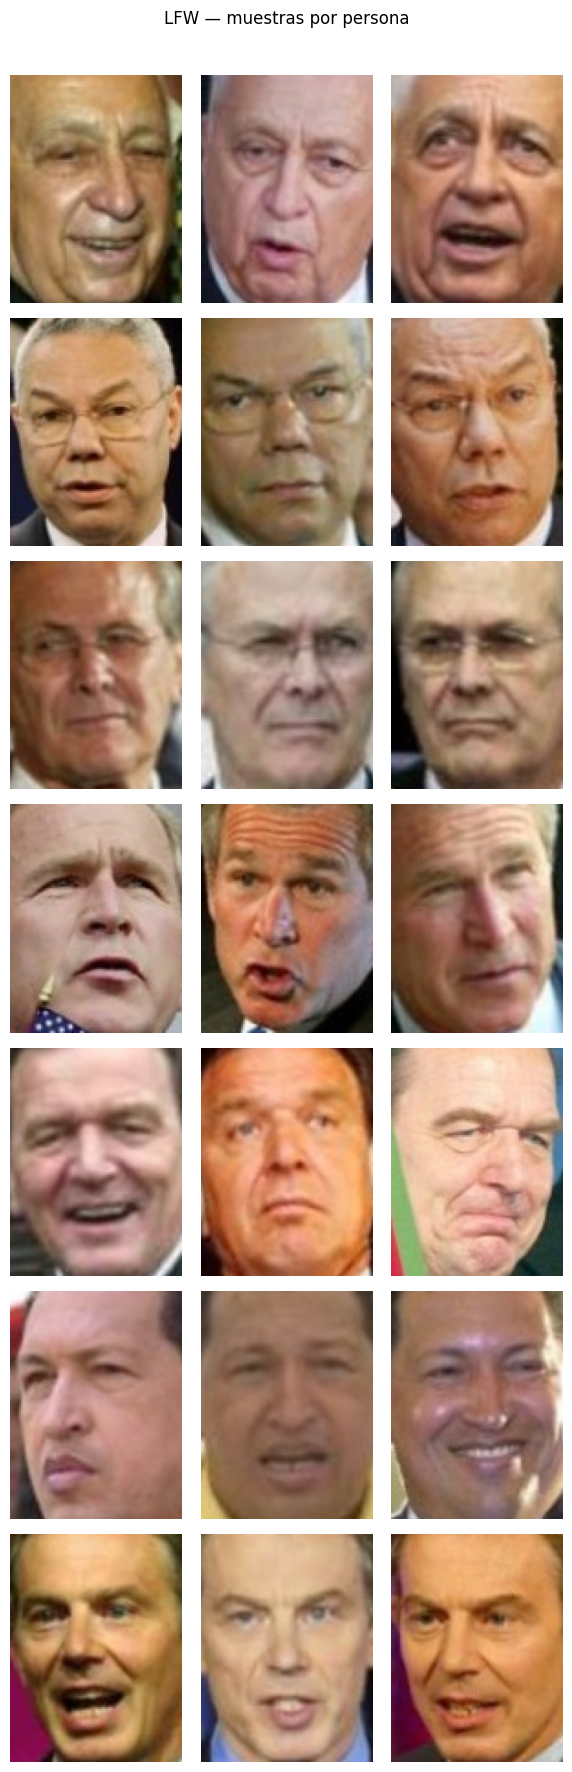

In [4]:
def lfw_to_pil(img_array):
    """Convierte una imagen LFW (float [0,1]) a PIL RGB."""
    return Image.fromarray((img_array * 255).astype(np.uint8))

# Seleccionar hasta MAX_IMG imágenes por persona (para que sea rápido)
MAX_IMG = 20
indices_sel = []
for persona_id in range(len(NOMBRES)):
    idxs = np.where(y_lfw == persona_id)[0][:MAX_IMG]
    indices_sel.extend(idxs)

X_sel = X_lfw[indices_sel]
y_sel = y_lfw[indices_sel]
print(f"Imágenes seleccionadas: {len(X_sel)} ({MAX_IMG} por persona)")

# Mostrar 3 imágenes por persona
fig, axes = plt.subplots(len(NOMBRES), 3, figsize=(6, 2.5 * len(NOMBRES)))
for i, nombre in enumerate(NOMBRES):
    idxs = np.where(y_sel == i)[0]
    for j in range(min(3, len(idxs))):
        axes[i, j].imshow(X_sel[idxs[j]])
        if j == 0:
            axes[i, j].set_ylabel(nombre.split()[-1], fontsize=9,
                                  rotation=0, labelpad=70, va="center")
        axes[i, j].axis("off")

plt.suptitle("LFW — muestras por persona", y=1.01)
plt.tight_layout()
plt.show()

---
# 2. Detección Facial

La detección responde: **¿hay caras en esta imagen?** y **¿dónde están?**

Usamos **MTCNN** (Multi-task Cascaded Convolutional Networks), un detector que funciona en 3 etapas:

1. **P-Net** — propone regiones candidatas a distintas escalas (rápido, muchos candidatos)
2. **R-Net** — refina las candidatas y descarta falsos positivos
3. **O-Net** — ajuste fino del bounding box + predicción de **5 landmarks** (ojos, nariz, comisuras)

La salida para cada cara detectada es:
- **Bounding box**: rectángulo `[x1, y1, x2, y2]`
- **Confianza**: probabilidad de que sea una cara (0 a 1)
- **Landmarks**: 5 puntos clave (ojo izq, ojo der, nariz, boca izq, boca der)

In [5]:
# Inicializar MTCNN
# image_size=160: tamaño de la cara recortada (lo que espera InceptionResnetV1)
# margin=20: píxeles extra alrededor de la cara al recortar
# keep_all=True: detectar TODAS las caras en la imagen
detector = MTCNN(
    image_size=160,
    margin=20,
    keep_all=True,
    device=device,
)
print(f"MTCNN inicializado en {device}")

MTCNN inicializado en cuda


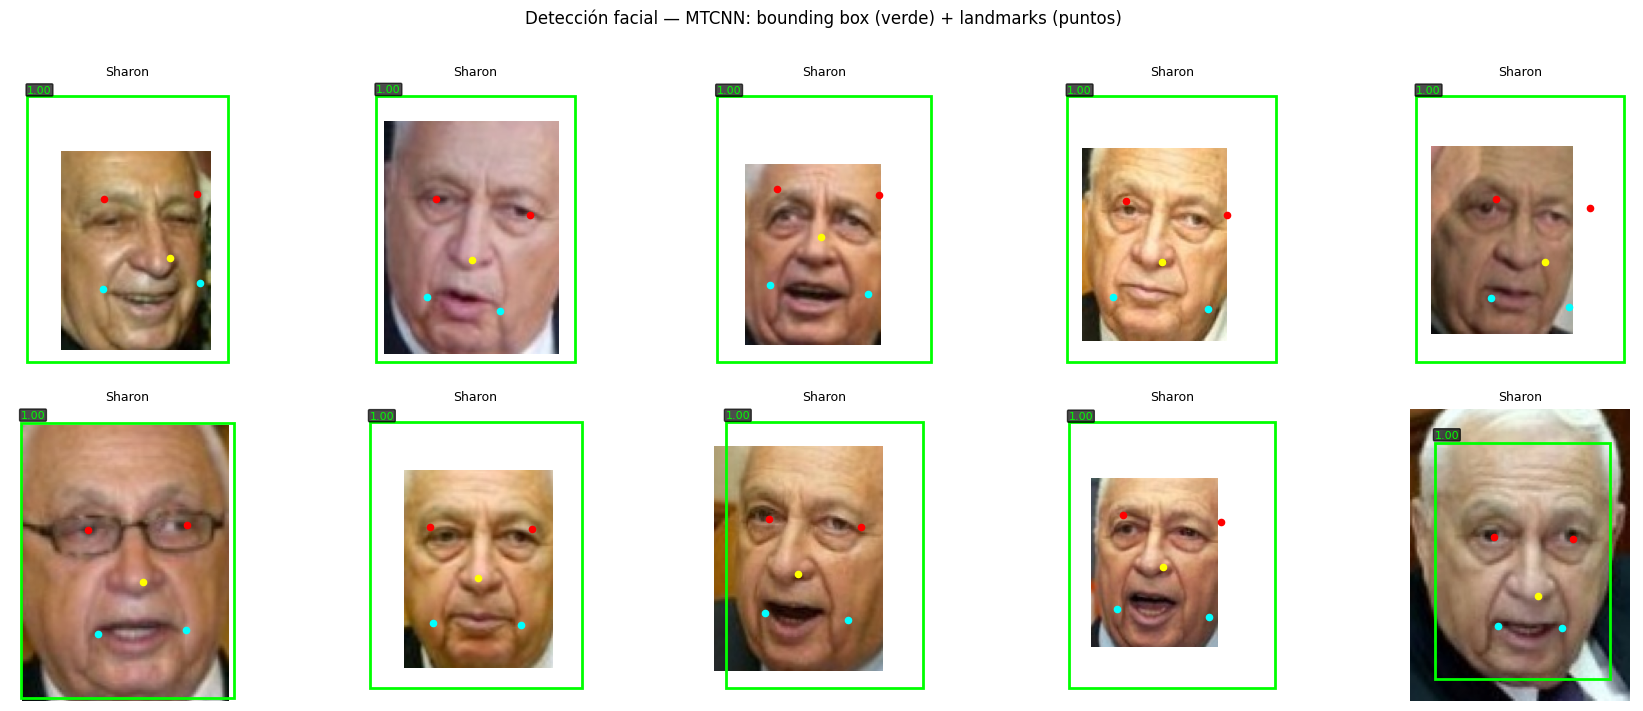

In [6]:
# Detectar caras en imágenes de LFW
# .detect() devuelve (boxes, probs, landmarks)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(10):
    pil = lfw_to_pil(X_sel[i])
    boxes, probs, landmarks = detector.detect(pil, landmarks=True)

    ax = axes[i]
    ax.imshow(pil)

    if boxes is not None:
        for box, prob, lm in zip(boxes, probs, landmarks):
            # Bounding box
            x1, y1, x2, y2 = box.astype(int)
            rect = mpatches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, color='lime', linewidth=2
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f"{prob:.2f}", color='lime', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.7))

            # Landmarks: ojo izq, ojo der, nariz, boca izq, boca der
            colores_lm = ['red', 'red', 'yellow', 'cyan', 'cyan']
            nombres_lm = ['OI', 'OD', 'N', 'BI', 'BD']
            for (lx, ly), c in zip(lm, colores_lm):
                ax.scatter(lx, ly, c=c, s=20, zorder=5)

    ax.set_title(NOMBRES[y_sel[i]].split()[-1], fontsize=9)
    ax.axis("off")

plt.suptitle("Detección facial — MTCNN: bounding box (verde) + landmarks (puntos)", y=1.01)
plt.tight_layout()
plt.show()

### ¿Qué hace MTCNN internamente?

MTCNN tiene **dos modos** de uso que vamos a aprovechar:

| Método | Qué devuelve | Para qué sirve |
|---|---|---|
| `detector.detect(img)` | boxes, probs, landmarks | **Detección**: saber dónde hay caras |
| `detector(img)` | tensor recortado y alineado | **Preprocesamiento**: cara lista para el modelo de embeddings |

El segundo modo recorta la cara usando los landmarks, la alinea y la redimensiona a 160×160.
Es el paso previo necesario antes de extraer embeddings.

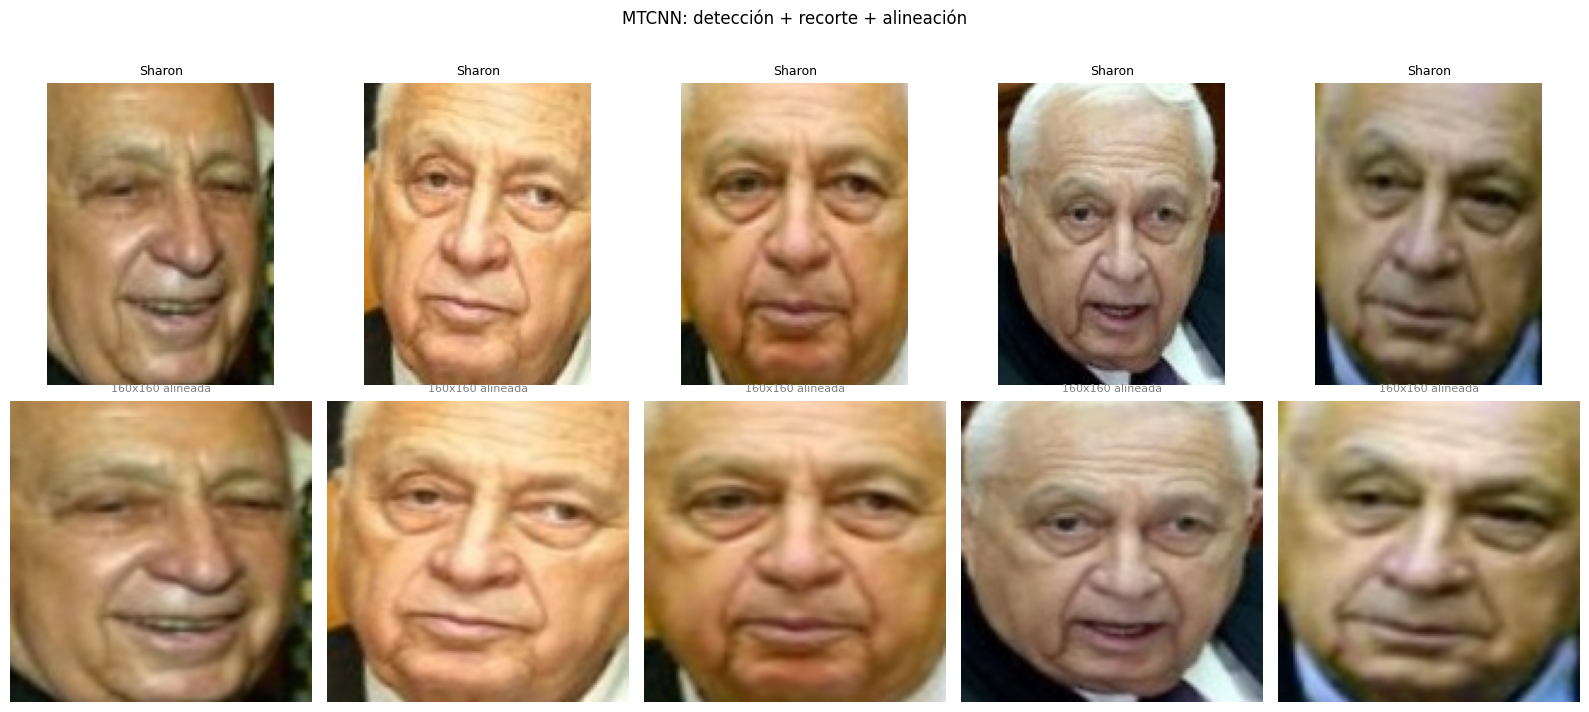

In [7]:
# Comparar: imagen original vs. cara recortada y alineada por MTCNN
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i in range(5):
    pil = lfw_to_pil(X_sel[i * 3])  # cada 3 para variar personas
    cara_tensor = detector(pil)       # (N, 3, 160, 160)

    # Fila 0: imagen original
    axes[0, i].imshow(pil)
    axes[0, i].set_title(NOMBRES[y_sel[i * 3]].split()[-1], fontsize=9)
    axes[0, i].axis("off")

    # Fila 1: cara recortada y alineada
    if cara_tensor is not None:
        # MTCNN devuelve valores en [-1, 1] con post_process; llevamos a [0, 1]
        cara_img = cara_tensor[0].permute(1, 2, 0).cpu().numpy()
        cara_img = (cara_img - cara_img.min()) / (cara_img.max() - cara_img.min())
        axes[1, i].imshow(cara_img)
    axes[1, i].set_title("160x160 alineada", fontsize=8, color='gray')
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10, rotation=0, labelpad=50, va="center")
axes[1, 0].set_ylabel("Recortada", fontsize=10, rotation=0, labelpad=50, va="center")
plt.suptitle("MTCNN: detección + recorte + alineación", y=1.01)
plt.tight_layout()
plt.show()

---
# 3. Extracción de Embeddings

Un **embedding facial** es un vector numérico que codifica la identidad de una persona.
Usamos **InceptionResnetV1** pre-entrenado en **VGGFace2** (3.3 millones de imágenes, 9131 identidades).

El modelo recibe una cara alineada de 160×160 y devuelve un **vector de 512 dimensiones**, normalizado (norma L2 = 1).

La propiedad clave:
- **Misma persona** → embeddings **cercanos** (alta similitud coseno)
- **Personas distintas** → embeddings **lejanos** (baja similitud coseno)

Como los embeddings están L2-normalizados, la **similitud coseno = producto punto**:

$$\text{sim}(e_1, e_2) = e_1 \cdot e_2 = \cos(\theta)$$

In [8]:
# Modelo de embeddings faciales
modelo = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print(f"InceptionResnetV1 cargado | Embedding: 512 dimensiones")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.1f}M")

100.0%


InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


In [9]:
# Extraer embeddings para todas las imágenes seleccionadas
# Pipeline: imagen → MTCNN (crop+align) → InceptionResnetV1 → embedding 512-d

embeddings = []
etiquetas = []
imagenes_ok = []  # guardamos las imágenes para visualizar después

print("Extrayendo embeddings...")
for i in range(len(X_sel)):
    pil = lfw_to_pil(X_sel[i])
    cara = detector(pil)  # (N, 3, 160, 160) o None

    if cara is not None:
        # Tomar la primera cara detectada
        cara_input = cara[0].unsqueeze(0).to(device)  # (1, 3, 160, 160)

        with torch.no_grad():
            emb = modelo(cara_input)  # (1, 512), ya L2-normalizado

        embeddings.append(emb.cpu().squeeze().numpy())
        etiquetas.append(y_sel[i])
        imagenes_ok.append(X_sel[i])

    if (i + 1) % 20 == 0:
        print(f"  {i + 1}/{len(X_sel)} procesadas...")

embeddings = np.array(embeddings)
etiquetas = np.array(etiquetas)

print(f"\nEmbeddings extraídos: {len(embeddings)} de {len(X_sel)} imágenes")
print(f"Dimensión: {embeddings.shape[1]}")
print(f"Norma L2 promedio: {np.linalg.norm(embeddings, axis=1).mean():.4f} (debería ser ~1.0)")

Extrayendo embeddings...
  20/140 procesadas...
  40/140 procesadas...
  60/140 procesadas...
  80/140 procesadas...
  100/140 procesadas...
  120/140 procesadas...
  140/140 procesadas...

Embeddings extraídos: 140 de 140 imágenes
Dimensión: 512
Norma L2 promedio: 1.0000 (debería ser ~1.0)


### Visualizar el espacio de embeddings con t-SNE

t-SNE reduce los embeddings de 512 dimensiones a 2D para poder visualizarlos.
Si el modelo funciona bien, las imágenes de la **misma persona** deberían agruparse juntas.

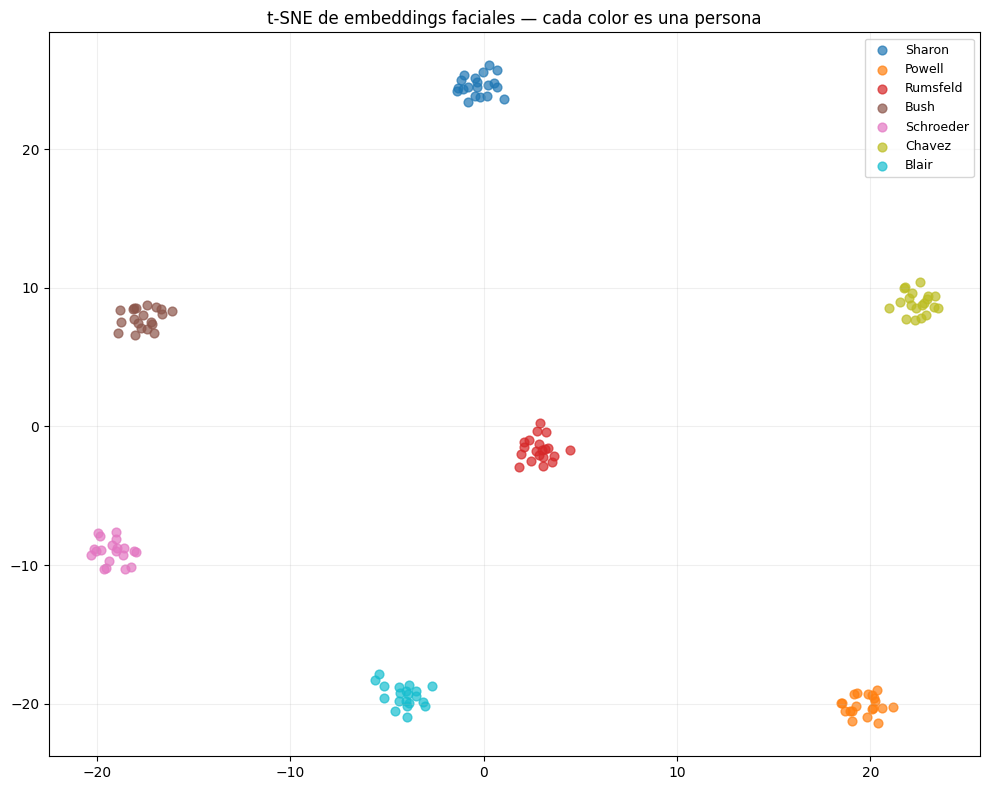

Si los clusters están bien separados, el modelo distingue bien las identidades.


In [10]:
tsne = TSNE(n_components=2, random_state=42, perplexity=min(15, len(embeddings) - 1))
emb_2d = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
colores = plt.cm.tab10(np.linspace(0, 1, len(NOMBRES)))

for persona_id, nombre in enumerate(NOMBRES):
    mask = etiquetas == persona_id
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
              label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])

ax.legend(fontsize=9, loc='best')
ax.set_title("t-SNE de embeddings faciales — cada color es una persona")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Si los clusters están bien separados, el modelo distingue bien las identidades.")

---
# 4. Verificación (1:1) — ¿Son la misma persona?

La verificación compara **dos caras** y responde: **¿son la misma persona?**

El procedimiento es:
1. Extraer el embedding de cada cara
2. Calcular la **similitud coseno** (producto punto, porque están normalizados)
3. Comparar contra un **umbral**: si `sim >= umbral` → misma persona

El umbral define el trade-off entre:
- **Falsos positivos** (aceptar impostores): umbral muy bajo
- **Falsos negativos** (rechazar personas legítimas): umbral muy alto

In [11]:
# Construir pares de verificación
np.random.seed(42)

# Pares POSITIVOS: dos imágenes de la misma persona
pares_pos = []
for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0]
    if len(idxs) >= 2:
        for _ in range(15):
            i, j = np.random.choice(idxs, 2, replace=False)
            pares_pos.append((i, j))

# Pares NEGATIVOS: dos imágenes de personas distintas
pares_neg = []
ids_personas = list(range(len(NOMBRES)))
for _ in range(len(pares_pos)):
    p1, p2 = np.random.choice(ids_personas, 2, replace=False)
    i = np.random.choice(np.where(etiquetas == p1)[0])
    j = np.random.choice(np.where(etiquetas == p2)[0])
    pares_neg.append((i, j))

print(f"Pares positivos (misma persona): {len(pares_pos)}")
print(f"Pares negativos (distinta persona): {len(pares_neg)}")

Pares positivos (misma persona): 105
Pares negativos (distinta persona): 105


Similitud positivos — media: 0.762, min: 0.560, max: 0.903
Similitud negativos — media: 0.151, min: -0.143, max: 0.543


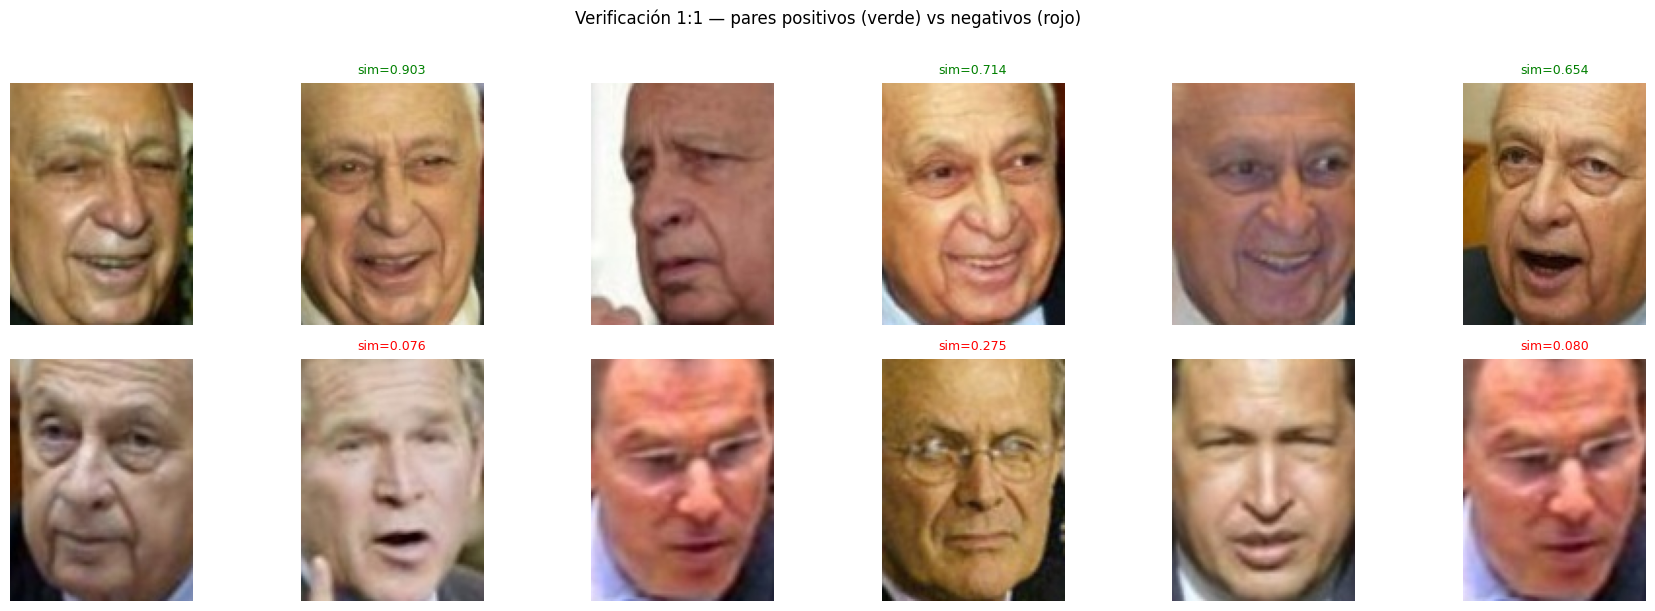

In [12]:
# Calcular similitudes
# Como los embeddings están L2-normalizados: sim coseno = producto punto
sims_pos = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_pos]
sims_neg = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_neg]

print(f"Similitud positivos — media: {np.mean(sims_pos):.3f}, min: {np.min(sims_pos):.3f}, max: {np.max(sims_pos):.3f}")
print(f"Similitud negativos — media: {np.mean(sims_neg):.3f}, min: {np.min(sims_neg):.3f}, max: {np.max(sims_neg):.3f}")

# Visualizar algunos pares
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Fila 0: pares positivos
for j in range(3):
    i1, i2 = pares_pos[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    axes[0, j*2].imshow(imagenes_ok[i1])
    axes[0, j*2].axis("off")
    axes[0, j*2+1].imshow(imagenes_ok[i2])
    axes[0, j*2+1].set_title(f"sim={sim:.3f}", fontsize=9, color='green')
    axes[0, j*2+1].axis("off")

# Fila 1: pares negativos
for j in range(3):
    i1, i2 = pares_neg[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    axes[1, j*2].imshow(imagenes_ok[i1])
    axes[1, j*2].axis("off")
    axes[1, j*2+1].imshow(imagenes_ok[i2])
    axes[1, j*2+1].set_title(f"sim={sim:.3f}", fontsize=9, color='red')
    axes[1, j*2+1].axis("off")

axes[0, 0].set_ylabel("Misma\npersona", fontsize=10, rotation=0, labelpad=50, va="center", color='green')
axes[1, 0].set_ylabel("Distinta\npersona", fontsize=10, rotation=0, labelpad=50, va="center", color='red')
plt.suptitle("Verificación 1:1 — pares positivos (verde) vs negativos (rojo)", y=1.01)
plt.tight_layout()
plt.show()

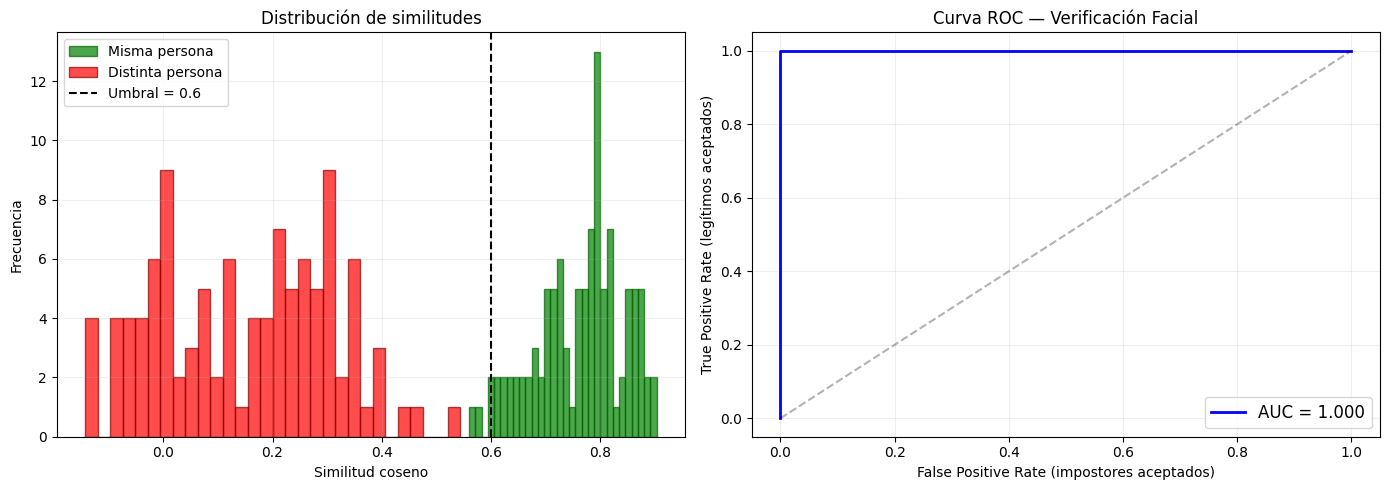

AUC: 1.000

Interpretación:
  AUC = 1.0 → separación perfecta entre positivos y negativos
  AUC = 0.5 → modelo random (no distingue nada)
  Cuanto menos se solapen los histogramas, mejor funciona el modelo.


In [13]:
# Histograma de similitudes + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(sims_pos, bins=30, alpha=0.7, label='Misma persona', color='green', edgecolor='darkgreen')
axes[0].hist(sims_neg, bins=30, alpha=0.7, label='Distinta persona', color='red', edgecolor='darkred')
axes[0].axvline(x=0.6, color='black', linestyle='--', label='Umbral = 0.6')
axes[0].set_xlabel('Similitud coseno')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de similitudes')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Curva ROC
y_true = [1] * len(sims_pos) + [0] * len(sims_neg)
y_scores = sims_pos + sims_neg
fpr, tpr, umbrales = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate (impostores aceptados)')
axes[1].set_ylabel('True Positive Rate (legítimos aceptados)')
axes[1].set_title('Curva ROC — Verificación Facial')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.3f}")
print(f"\nInterpretación:")
print(f"  AUC = 1.0 → separación perfecta entre positivos y negativos")
print(f"  AUC = 0.5 → modelo random (no distingue nada)")
print(f"  Cuanto menos se solapen los histogramas, mejor funciona el modelo.")

### Función de verificación

Encapsulamos la lógica en una función reutilizable.

In [14]:
def verificar(emb1, emb2, umbral=0.6):
    """Verificación 1:1. Devuelve si son la misma persona + similitud."""
    sim = float(np.dot(emb1, emb2))
    return {"misma_persona": sim >= umbral, "similitud": round(sim, 4), "umbral": umbral}

# Probar con un par positivo y uno negativo
i1, i2 = pares_pos[0]
r = verificar(embeddings[i1], embeddings[i2])
print(f"Par positivo: {r}")

i1, i2 = pares_neg[0]
r = verificar(embeddings[i1], embeddings[i2])
print(f"Par negativo: {r}")

Par positivo: {'misma_persona': True, 'similitud': 0.9029, 'umbral': 0.6}
Par negativo: {'misma_persona': False, 'similitud': 0.0764, 'umbral': 0.6}


---
# 5. Identificación (1:N) — ¿Quién es esta persona?

La identificación busca **quién es** una persona dentro de una **galería de identidades conocidas**.

El procedimiento:
1. Tener una **galería**: conjunto de embeddings de personas conocidas
2. Recibir una **cara de consulta** (query)
3. Calcular la similitud del query contra **todos** los embeddings de la galería
4. El más similar es la identidad predicha (**Rank-1**)

Dividimos nuestros datos: 15 imágenes por persona para la galería, el resto para consultas.

In [15]:
# Dividir en galería y consultas (queries)
np.random.seed(42)

gal_embs, gal_labels, gal_imgs = [], [], []
qry_embs, qry_labels, qry_imgs = [], [], []

for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0].copy()
    np.random.shuffle(idxs)
    n_gal = min(15, len(idxs) - 2)  # dejar al menos 2 para queries

    for idx in idxs[:n_gal]:
        gal_embs.append(embeddings[idx])
        gal_labels.append(persona_id)
        gal_imgs.append(imagenes_ok[idx])

    for idx in idxs[n_gal:]:
        qry_embs.append(embeddings[idx])
        qry_labels.append(persona_id)
        qry_imgs.append(imagenes_ok[idx])

gal_embs = np.array(gal_embs)
gal_labels = np.array(gal_labels)
qry_embs = np.array(qry_embs)
qry_labels = np.array(qry_labels)

print(f"Galería: {len(gal_embs)} embeddings")
print(f"Consultas: {len(qry_embs)} embeddings")

Galería: 105 embeddings
Consultas: 35 embeddings


In [16]:
# Identificación: para cada query, buscar el más similar en la galería
# Similitud coseno en batch: producto punto de matrices
sims_matrix = qry_embs @ gal_embs.T  # (n_queries, n_galeria)

# Rank-1: el más similar
best_match_idx = sims_matrix.argmax(axis=1)
predicciones = gal_labels[best_match_idx]
accuracy_r1 = (predicciones == qry_labels).mean()

print(f"Accuracy Rank-1: {accuracy_r1:.3f} ({(predicciones == qry_labels).sum()}/{len(qry_labels)})")
print(f"\nAccuracy por persona:")
for persona_id, nombre in enumerate(NOMBRES):
    mask = qry_labels == persona_id
    if mask.sum() > 0:
        acc = (predicciones[mask] == persona_id).mean()
        print(f"  {nombre}: {acc:.3f} ({(predicciones[mask] == persona_id).sum()}/{mask.sum()})")

Accuracy Rank-1: 1.000 (35/35)

Accuracy por persona:
  Ariel Sharon: 1.000 (5/5)
  Colin Powell: 1.000 (5/5)
  Donald Rumsfeld: 1.000 (5/5)
  George W Bush: 1.000 (5/5)
  Gerhard Schroeder: 1.000 (5/5)
  Hugo Chavez: 1.000 (5/5)
  Tony Blair: 1.000 (5/5)


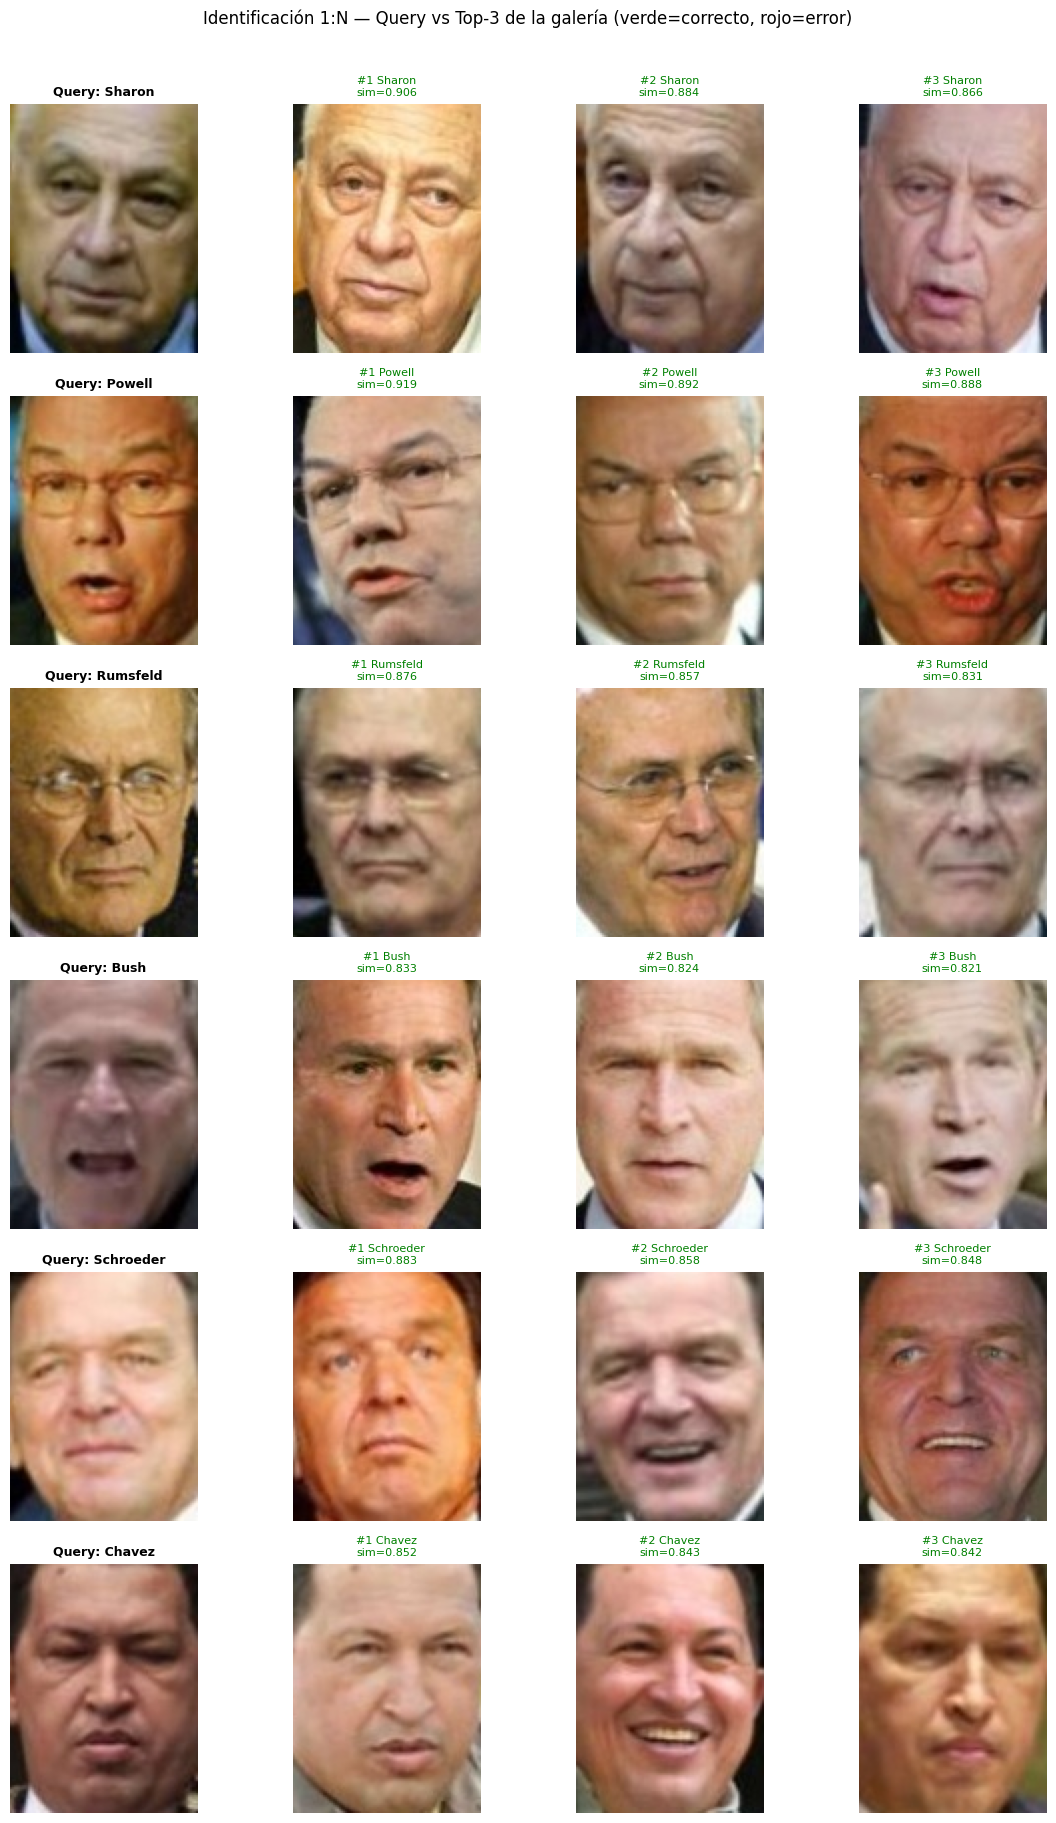

In [17]:
# Visualizar resultados de identificación: query + top-3 candidatos
n_show = min(6, len(qry_embs))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 3 * n_show))

# Elegir queries variados (uno por persona si es posible)
show_idxs = []
for persona_id in range(len(NOMBRES)):
    candidatos = np.where(qry_labels == persona_id)[0]
    if len(candidatos) > 0:
        show_idxs.append(candidatos[0])
show_idxs = show_idxs[:n_show]

for row, q_idx in enumerate(show_idxs):
    top3 = sims_matrix[q_idx].argsort()[::-1][:3]

    # Columna 0: query
    axes[row, 0].imshow(qry_imgs[q_idx])
    axes[row, 0].set_title(f"Query: {NOMBRES[qry_labels[q_idx]].split()[-1]}",
                           fontsize=9, fontweight='bold')
    axes[row, 0].axis("off")

    # Columnas 1-3: top-3 de la galería
    for j, match_idx in enumerate(top3):
        correcto = gal_labels[match_idx] == qry_labels[q_idx]
        color = "green" if correcto else "red"
        sim_val = sims_matrix[q_idx, match_idx]

        axes[row, j + 1].imshow(gal_imgs[match_idx])
        axes[row, j + 1].set_title(
            f"#{j+1} {NOMBRES[gal_labels[match_idx]].split()[-1]}\nsim={sim_val:.3f}",
            fontsize=8, color=color
        )
        axes[row, j + 1].axis("off")

plt.suptitle("Identificación 1:N — Query vs Top-3 de la galería (verde=correcto, rojo=error)", y=1.01)
plt.tight_layout()
plt.show()

---
# 6. Pipeline Completo de Reconocimiento

Ahora combinamos todo en un **pipeline end-to-end**:

```
Imagen → Detección (MTCNN) → Alineación → Embedding (InceptionResnetV1) → Identificación (vs galería)
```

Esto es lo que haría un sistema de reconocimiento facial en producción,
desde una foto cruda hasta la identidad de las personas detectadas.

In [18]:
def pipeline_reconocimiento(img_pil, galeria_embs, galeria_labels, nombres, umbral=0.4):
    """
    Pipeline completo: imagen PIL → identidades detectadas.

    Retorna dict con:
      - caras: cantidad de caras detectadas
      - resultados: lista de dicts con identidad, similitud, bbox, confianza
    """
    # 1. Detección: encontrar caras
    boxes, probs, landmarks = detector.detect(img_pil, landmarks=True)
    if boxes is None:
        return {"caras": 0, "resultados": []}

    # 2. Crop + alineación
    caras_tensor = detector(img_pil)  # (N, 3, 160, 160)
    if caras_tensor is None:
        return {"caras": 0, "resultados": []}

    # 3. Extraer embeddings
    with torch.no_grad():
        embs = modelo(caras_tensor.to(device)).cpu().numpy()  # (N, 512)

    # 4. Identificación contra la galería
    resultados = []
    for i, (emb, box, prob) in enumerate(zip(embs, boxes, probs)):
        sims = emb @ galeria_embs.T
        best_idx = sims.argmax()
        best_sim = float(sims[best_idx])

        identidad = nombres[galeria_labels[best_idx]] if best_sim >= umbral else "Desconocido"

        resultados.append({
            "identidad": identidad,
            "similitud": round(best_sim, 4),
            "bbox": box,
            "confianza_deteccion": round(float(prob), 4),
        })

    return {"caras": len(resultados), "resultados": resultados}

print("Función pipeline_reconocimiento() definida.")

Función pipeline_reconocimiento() definida.


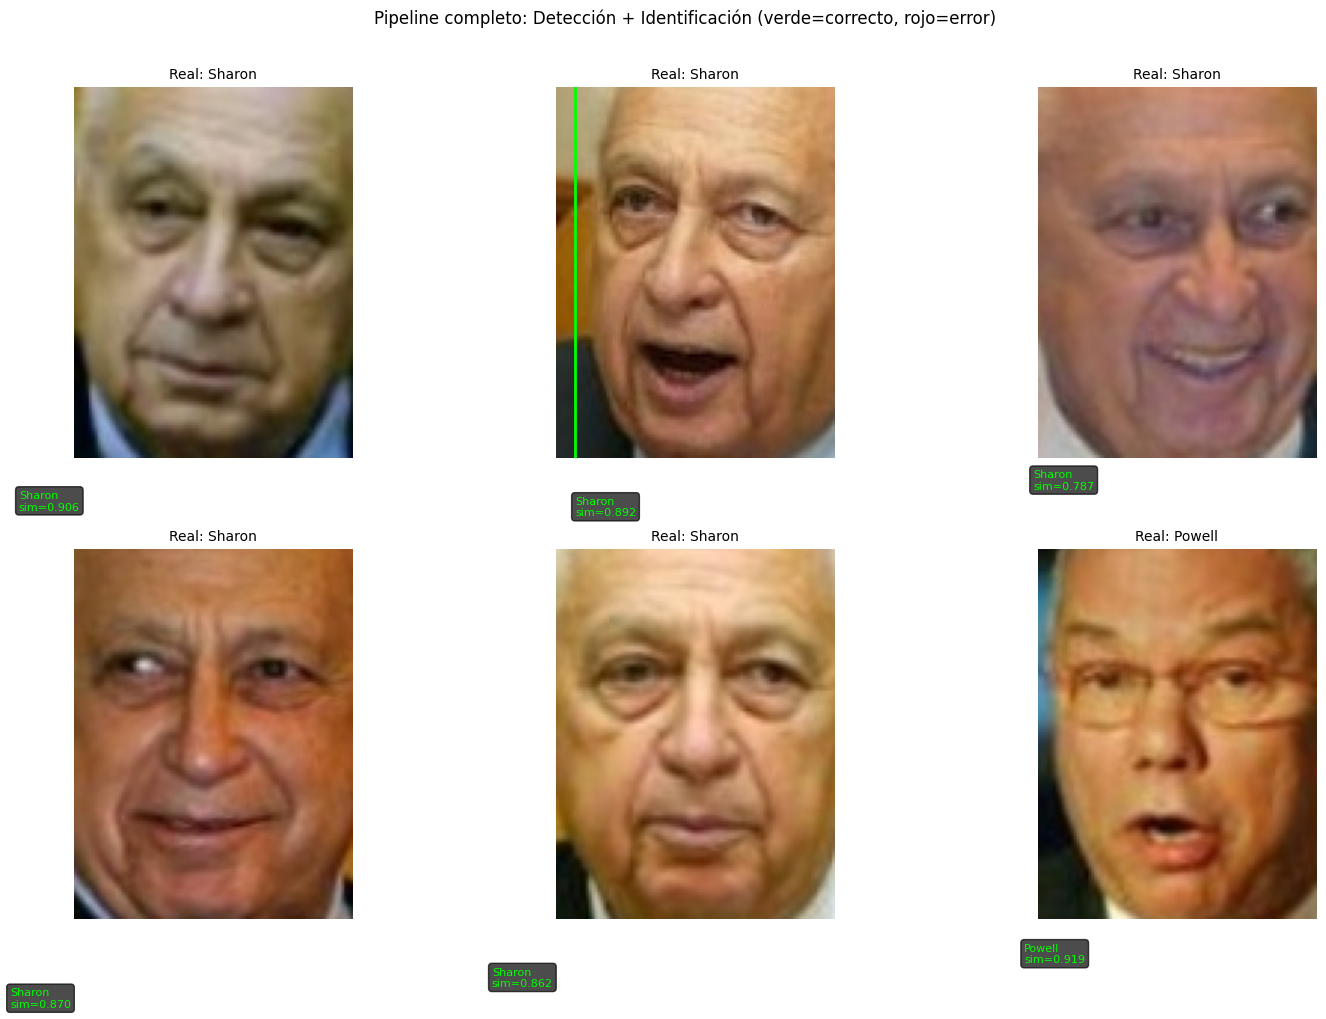

In [19]:
# Demo del pipeline completo sobre imágenes de consulta
n_demo = min(6, len(qry_imgs))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_demo):
    pil = lfw_to_pil(qry_imgs[i])
    resultado = pipeline_reconocimiento(pil, gal_embs, gal_labels, NOMBRES)

    ax = axes[i]
    ax.imshow(pil)

    real = NOMBRES[qry_labels[i]].split()[-1]

    for r in resultado["resultados"]:
        x1, y1, x2, y2 = r["bbox"].astype(int)
        pred = r["identidad"].split()[-1] if r["identidad"] != "Desconocido" else "?"
        correcto = pred == real
        color = 'lime' if correcto else 'red'

        rect = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  fill=False, color=color, linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y2 + 10,
                f"{r['identidad'].split()[-1]}\nsim={r['similitud']:.3f}",
                color=color, fontsize=8,
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

    ax.set_title(f"Real: {real}", fontsize=10)
    ax.axis("off")

plt.suptitle("Pipeline completo: Detección + Identificación (verde=correcto, rojo=error)", y=1.01)
plt.tight_layout()
plt.show()

---
# 7. Verificación dentro del pipeline

Podemos también integrar la **verificación 1:1** al pipeline.
Esto es útil cuando queremos confirmar si una persona específica está en la imagen
(ejemplo: desbloqueo facial de un celular).

In [20]:
def pipeline_verificacion(img_pil, emb_referencia, umbral=0.6):
    """
    Verificación: detecta caras en la imagen y compara cada una
    contra un embedding de referencia.
    """
    caras_tensor = detector(img_pil)
    if caras_tensor is None:
        return {"verificado": False, "caras": 0, "similitudes": []}

    with torch.no_grad():
        embs = modelo(caras_tensor.to(device)).cpu().numpy()

    similitudes = [float(np.dot(emb, emb_referencia)) for emb in embs]
    verificado = any(s >= umbral for s in similitudes)

    return {
        "verificado": verificado,
        "caras": len(embs),
        "similitudes": [round(s, 4) for s in similitudes],
        "umbral": umbral,
    }

# Demo: verificar si una persona específica está en la imagen
# Usamos el primer embedding de la galería como referencia
persona_ref = 0
emb_ref = gal_embs[gal_labels == persona_ref][0]
print(f"Referencia: {NOMBRES[persona_ref]}\n")

# Probar con queries de la misma persona y de otra
for persona_test in [persona_ref, (persona_ref + 1) % len(NOMBRES)]:
    idxs_test = np.where(qry_labels == persona_test)[0]
    if len(idxs_test) > 0:
        pil = lfw_to_pil(qry_imgs[idxs_test[0]])
        res = pipeline_verificacion(pil, emb_ref)
        estado = "VERIFICADO" if res["verificado"] else "NO VERIFICADO"
        print(f"  {NOMBRES[persona_test]}: {estado} (sim={res['similitudes']})")

Referencia: Ariel Sharon

  Ariel Sharon: VERIFICADO (sim=[0.7618])
  Colin Powell: NO VERIFICADO (sim=[0.0671])


---
# Ejercicios

Cada ejercicio tiene una celda con código esqueleto como guía.
Descomentá, completá los huecos y ejecutá.

## Ejercicio 1 — Umbral óptimo de verificación

El umbral de verificación controla el trade-off entre seguridad y usabilidad.

1. Barré umbrales de 0.0 a 1.0 (en pasos de 0.01)
2. Para cada umbral, calculá el **accuracy** sobre los pares positivos y negativos
3. Graficá accuracy vs umbral
4. Encontrá el umbral que maximiza el accuracy

> **Tip:** un par positivo es correcto si `sim >= umbral`.
> Un par negativo es correcto si `sim < umbral`.

In [21]:
# Ejercicio 1 — completar aquí

# 1. Definir rango de umbrales
# umbrales = np.arange(0.0, 1.01, 0.01)

# 2. Para cada umbral, calcular accuracy
# accuracies = []
# for umbral in umbrales:
#     tp = sum(1 for s in sims_pos if s >= umbral)   # positivos correctos
#     tn = sum(1 for s in sims_neg if _____)          # negativos correctos
#     acc = (tp + tn) / (len(sims_pos) + len(sims_neg))
#     accuracies.append(acc)

# 3. Graficar
# plt.figure(figsize=(10, 5))
# plt.plot(umbrales, accuracies)
# plt.xlabel('Umbral')
# plt.ylabel('Accuracy')
# plt.title('Accuracy vs Umbral de verificación')
# plt.grid(alpha=0.3)
# plt.show()

# 4. Encontrar el óptimo
# mejor_idx = np.argmax(accuracies)
# print(f"Umbral óptimo: {umbrales[mejor_idx]:.2f} (accuracy: {accuracies[mejor_idx]:.3f})")

## Ejercicio 2 — Rank-K accuracy

En identificación, **Rank-1** significa que el candidato más similar es la persona correcta.
Pero a veces la persona correcta está entre los **top-5** aunque no sea el primero.

1. Implementá una función que calcule la accuracy para Rank-1, Rank-3 y Rank-5
2. Graficá la **Cumulative Match Characteristic (CMC)** curve: accuracy vs rank

> **Tip:** para Rank-K, la predicción es correcta si la persona real está entre los top-K más similares.

In [22]:
# Ejercicio 2 — completar aquí

# def rank_k_accuracy(sims_matrix, qry_labels, gal_labels, k):
#     """Calcula accuracy Rank-K."""
#     correctos = 0
#     for i in range(len(qry_labels)):
#         # top-k índices de la galería, ordenados por similitud descendente
#         top_k_idx = sims_matrix[i].argsort()[::-1][:___]
#         top_k_labels = gal_labels[top_k_idx]
#         if qry_labels[i] in _____:
#             correctos += 1
#     return correctos / len(qry_labels)

# ranks = range(1, min(len(gal_embs), 20) + 1)
# accuracies = [rank_k_accuracy(sims_matrix, qry_labels, gal_labels, k) for k in ranks]

# plt.figure(figsize=(10, 5))
# plt.plot(ranks, accuracies, 'bo-')
# plt.xlabel('Rank')
# plt.ylabel('Accuracy')
# plt.title('Curva CMC — Cumulative Match Characteristic')
# plt.grid(alpha=0.3)
# plt.show()

# for k in [1, 3, 5]:
#     print(f"Rank-{k}: {rank_k_accuracy(sims_matrix, qry_labels, gal_labels, k):.3f}")

## Ejercicio 3 — Robustez a transformaciones

¿Qué pasa con la similitud si la imagen de consulta tiene **ruido, blur o cambio de brillo**?

1. Tomá una imagen de consulta y su embedding original
2. Aplicá transformaciones: blur gaussiano, ruido, cambio de brillo
3. Extraé embeddings de las imágenes transformadas
4. Compará la similitud con el embedding original

> **Pregunta:** ¿Cuál de las transformaciones afecta más al reconocimiento? ¿Por qué?

In [23]:
# Ejercicio 3 — completar aquí
from PIL import ImageFilter, ImageEnhance

# 1. Elegir una imagen de consulta
# idx_test = 0
# pil_original = lfw_to_pil(qry_imgs[idx_test])
# emb_original = qry_embs[idx_test]

# 2. Aplicar transformaciones
# transformaciones = {
#     "Original": pil_original,
#     "Blur leve": pil_original.filter(ImageFilter.GaussianBlur(radius=1)),
#     "Blur fuerte": pil_original.filter(ImageFilter.GaussianBlur(radius=___)),
#     "Oscura": ImageEnhance.Brightness(pil_original).enhance(0.4),
#     "Brillante": ImageEnhance.Brightness(pil_original).enhance(___),
# }

# 3. Extraer embeddings y comparar
# fig, axes = plt.subplots(1, len(transformaciones), figsize=(16, 3))
# for i, (nombre, pil_t) in enumerate(transformaciones.items()):
#     cara = detector(pil_t)
#     if cara is not None:
#         with torch.no_grad():
#             emb_t = modelo(cara[0].unsqueeze(0).to(device)).cpu().squeeze().numpy()
#         sim = np.dot(emb_original, emb_t)
#     else:
#         sim = 0.0
#     axes[i].imshow(pil_t)
#     axes[i].set_title(f"{nombre}\nsim={sim:.3f}", fontsize=9)
#     axes[i].axis("off")
# plt.tight_layout()
# plt.show()

## Ejercicio 4 — Persona desconocida

¿Qué pasa cuando el pipeline recibe una cara que **no está en la galería**?

1. Cargá imágenes del dataset LFW de personas que **no** están en nuestra galería
   (usá `fetch_lfw_people(min_faces_per_person=50)` para obtener más personas y elegí una nueva)
2. Pasá esas imágenes por el pipeline con distintos umbrales (0.3, 0.5, 0.7)
3. Analizá: ¿con qué umbral el sistema correctamente dice "Desconocido"?

> **Pregunta:** ¿Qué trade-off hay entre detectar desconocidos y aceptar conocidos?

In [24]:
# Ejercicio 4 — completar aquí

# 1. Cargar más personas de LFW
# lfw_extra = fetch_lfw_people(min_faces_per_person=50, color=True, resize=1.0)
# nombres_extra = lfw_extra.target_names

# 2. Encontrar personas que NO están en nuestra galería
# personas_nuevas = [n for n in nombres_extra if n not in NOMBRES]
# print(f"Personas nuevas disponibles: {personas_nuevas}")

# 3. Elegir una persona nueva y obtener su imagen
# persona_nueva = personas_nuevas[0]
# idx_nueva = np.where(lfw_extra.target_names == persona_nueva)[0][0]
# idx_img = np.where(lfw_extra.target == idx_nueva)[0][0]
# pil_nueva = lfw_to_pil(lfw_extra.images[idx_img])

# 4. Probar con distintos umbrales
# for umbral in [0.3, 0.5, 0.7]:
#     res = pipeline_reconocimiento(pil_nueva, gal_embs, gal_labels, NOMBRES, umbral=umbral)
#     for r in res["resultados"]:
#         print(f"  umbral={umbral}: {r['identidad']} (sim={r['similitud']})")

---
# Conclusiones

Implementamos un sistema completo de reconocimiento facial con 4 etapas secuenciales:

| Etapa | Herramienta | Qué hace |
|---|---|---|
| **Detección** | MTCNN | Encuentra caras + landmarks en la imagen |
| **Alineación** | MTCNN (crop) | Recorta y normaliza la cara a 160×160 |
| **Embedding** | InceptionResnetV1 | Genera un vector de 512-d que codifica la identidad |
| **Verificación / Identificación** | Similitud coseno | Compara embeddings para decidir |

**Conceptos clave de esta práctica:**

- La **detección** localiza caras; la **verificación** compara dos caras; la **identificación** busca en una galería
- Los **embeddings** son representaciones numéricas que capturan la identidad facial
- La **similitud coseno** entre embeddings L2-normalizados se calcula como un simple producto punto
- El **umbral** controla el trade-off entre falsos positivos y falsos negativos
- La **curva ROC** y el **AUC** miden qué tan bien separa el modelo entre positivos y negativos
- El **Rank-K accuracy** mide la calidad de la identificación a distintos niveles de tolerancia

**En la clase anterior** vimos cómo **ViT** puede usarse como backbone para generar embeddings faciales.
En esta práctica usamos **InceptionResnetV1** (una CNN), pero el pipeline es idéntico:
lo que cambia es el modelo que genera el embedding, no la lógica de verificación/identificación.